# Walmart Retail Analytics: Sales Trends, Store Performance & Forecasting

### Data Period: February 2010 – October 2012 | Dataset: 421,570 rows

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
plt.style.use('dark_background')
sns.set_palette("YlOrBr")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Data

In [9]:
df = pd.read_csv("WALMART_CLEAN.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (421570, 22)

Columns: ['STORE', 'DEPT', 'SALE_DATE', 'YEAR', 'MONTH', 'QUARTER', 'WEEK_NUMBER', 'WEEKLY_SALES', 'IS_HOLIDAY', 'IS_RETURN', 'STORE_TYPE', 'STORE_SIZE', 'TEMPERATURE', 'FUEL_PRICE', 'MARKDOWN1', 'MARKDOWN2', 'MARKDOWN3', 'MARKDOWN4', 'MARKDOWN5', 'CPI', 'UNEMPLOYMENT', 'TOTAL_MARKDOWN']

First 5 rows:


,STORE,DEPT,SALE_DATE,YEAR,MONTH,QUARTER,WEEK_NUMBER,WEEKLY_SALES,IS_HOLIDAY,IS_RETURN,...,TEMPERATURE,FUEL_PRICE,MARKDOWN1,MARKDOWN2,MARKDOWN3,MARKDOWN4,MARKDOWN5,CPI,UNEMPLOYMENT,TOTAL_MARKDOWN
0,1,1,05-02-10,2010,2,1,5,24924.50,False,False,...,42.31,2.57,0.00,0.00,0.00,0.00,0.00,211.10,8.11,0.00
1,1,1,12-02-10,2010,2,1,6,46039.49,True,False,...,38.51,2.55,0.00,0.00,0.00,0.00,0.00,211.24,8.11,0.00
2,1,1,19-02-10,2010,2,1,7,41595.55,False,False,...,39.93,2.51,0.00,0.00,0.00,0.00,0.00,211.29,8.11,0.00
3,1,1,26-02-10,2010,2,1,8,19403.54,False,False,...,46.63,2.56,0.00,0.00,0.00,0.00,0.00,211.32,8.11,0.00
4,1,1,05-03-10,2010,3,1,9,21827.90,False,False,...,46.50,2.62,0.00,0.00,0.00,0.00,0.00,211.35,8.11,0.00


## Basic Info

In [10]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   STORE           421570 non-null  int64  
 1   DEPT            421570 non-null  int64  
 2   SALE_DATE       421570 non-null  str    
 3   YEAR            421570 non-null  int64  
 4   MONTH           421570 non-null  int64  
 5   QUARTER         421570 non-null  int64  
 6   WEEK_NUMBER     421570 non-null  int64  
 7   WEEKLY_SALES    421570 non-null  float64
 8   IS_HOLIDAY      421570 non-null  bool   
 9   IS_RETURN       421570 non-null  bool   
 10  STORE_TYPE      421570 non-null  str    
 11  STORE_SIZE      421570 non-null  int64  
 12  TEMPERATURE     421570 non-null  float64
 13  FUEL_PRICE      421570 non-null  float64
 14  MARKDOWN1       421570 non-null  float64
 15  MARKDOWN2       421570 non-null  float64
 16  MARKDOWN3       421570 non-null  float64
 17  MARKDOW

,STORE,DEPT,YEAR,MONTH,QUARTER,WEEK_NUMBER,WEEKLY_SALES,STORE_SIZE,TEMPERATURE,FUEL_PRICE,MARKDOWN1,MARKDOWN2,MARKDOWN3,MARKDOWN4,MARKDOWN5,CPI,UNEMPLOYMENT,TOTAL_MARKDOWN
count,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00
mean,22.20,44.26,2010.97,6.45,2.48,25.83,15981.47,136727.92,60.09,3.36,2590.07,879.97,468.09,1083.13,1662.77,171.20,7.96,6684.04
std,12.79,30.49,0.80,3.24,1.07,14.15,22711.03,60980.58,18.45,0.46,6052.39,5084.54,5528.87,3894.53,4207.63,39.16,1.86,14750.94
min,1.00,1.00,2010.00,1.00,1.00,1.00,0.00,34875.00,-2.06,2.47,0.00,-265.76,-29.10,0.00,0.00,126.06,3.88,0.00
25%,11.00,18.00,2010.00,4.00,2.00,14.00,2079.65,93638.00,46.68,2.93,0.00,0.00,0.00,0.00,0.00,132.02,6.89,0.00
50%,22.00,37.00,2011.00,6.00,2.00,26.00,7612.03,140167.00,62.09,3.45,0.00,0.00,0.00,0.00,0.00,182.32,7.87,0.00
75%,33.00,74.00,2012.00,9.00,3.00,38.00,20205.85,202505.00,74.28,3.74,2809.05,2.20,4.54,425.29,2168.04,212.42,8.57,8075.26
max,45.00,99.00,2012.00,12.00,4.00,52.00,693099.36,219622.00,100.14,4.47,88646.76,104519.54,141630.61,67474.85,108519.28,227.23,14.31,160510.61


## Check Data Quality

In [12]:
print("Null Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Null Values:
STORE             0
DEPT              0
SALE_DATE         0
YEAR              0
MONTH             0
QUARTER           0
WEEK_NUMBER       0
WEEKLY_SALES      0
IS_HOLIDAY        0
IS_RETURN         0
STORE_TYPE        0
STORE_SIZE        0
TEMPERATURE       0
FUEL_PRICE        0
MARKDOWN1         0
MARKDOWN2         0
MARKDOWN3         0
MARKDOWN4         0
MARKDOWN5         0
CPI               0
UNEMPLOYMENT      0
TOTAL_MARKDOWN    0
dtype: int64

Duplicates: 0

Data Types:
STORE               int64
DEPT                int64
SALE_DATE             str
YEAR                int64
MONTH               int64
QUARTER             int64
WEEK_NUMBER         int64
WEEKLY_SALES      float64
IS_HOLIDAY           bool
IS_RETURN            bool
STORE_TYPE            str
STORE_SIZE          int64
TEMPERATURE       float64
FUEL_PRICE        float64
MARKDOWN1         float64
MARKDOWN2         float64
MARKDOWN3         float64
MARKDOWN4         float64
MARKDOWN5         float64
CPI         

**Fix Date Column**

In [17]:
df['SALE_DATE'] = pd.to_datetime(df['SALE_DATE'])
print("SALE_DATE dtype:", df['SALE_DATE'].dtype)
print("Date range:", df['SALE_DATE'].min(), "to", df['SALE_DATE'].max())

SALE_DATE dtype: datetime64[us]
Date range: 2010-01-10 00:00:00 to 2012-12-10 00:00:00


**EDA Visualizations**

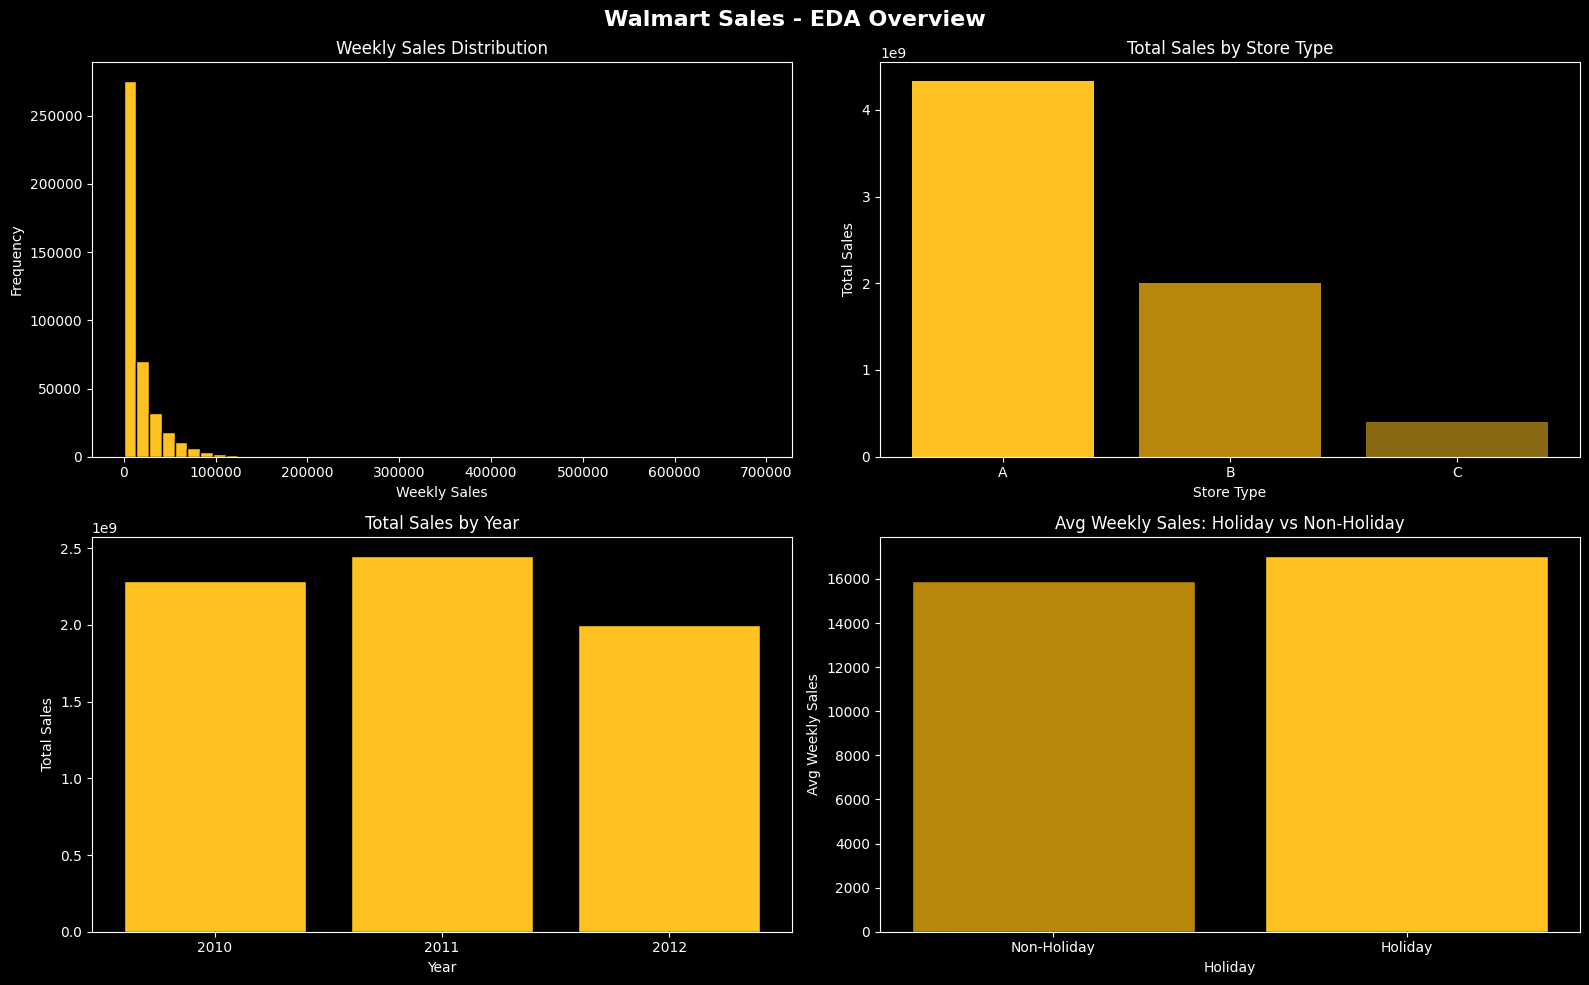

Plot saved!


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Walmart Sales - EDA Overview', fontsize=16, fontweight='bold')

# 1. Weekly Sales Distribution
axes[0,0].hist(df['WEEKLY_SALES'], bins=50, color='#FFC220', edgecolor='black')
axes[0,0].set_title('Weekly Sales Distribution')
axes[0,0].set_xlabel('Weekly Sales')
axes[0,0].set_ylabel('Frequency')

# 2. Sales by Store Type
store_type_sales = df.groupby('STORE_TYPE')['WEEKLY_SALES'].sum().reset_index()
axes[0,1].bar(store_type_sales['STORE_TYPE'], store_type_sales['WEEKLY_SALES'], 
              color=['#FFC220', '#B8860B', '#8B6914'])
axes[0,1].set_title('Total Sales by Store Type')
axes[0,1].set_xlabel('Store Type')
axes[0,1].set_ylabel('Total Sales')

# 3. Sales by Year
yearly_sales = df.groupby('YEAR')['WEEKLY_SALES'].sum().reset_index()
axes[1,0].bar(yearly_sales['YEAR'].astype(str), yearly_sales['WEEKLY_SALES'], 
              color='#FFC220', edgecolor='black')
axes[1,0].set_title('Total Sales by Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Total Sales')

# 4. Holiday vs Non-Holiday
holiday_sales = df.groupby('IS_HOLIDAY')['WEEKLY_SALES'].mean().reset_index()
axes[1,1].bar(['Non-Holiday', 'Holiday'], holiday_sales['WEEKLY_SALES'], 
              color=['#B8860B', '#FFC220'], edgecolor='black')
axes[1,1].set_title('Avg Weekly Sales: Holiday vs Non-Holiday')
axes[1,1].set_xlabel('Holiday')
axes[1,1].set_ylabel('Avg Weekly Sales')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

## Correlation Heatmap

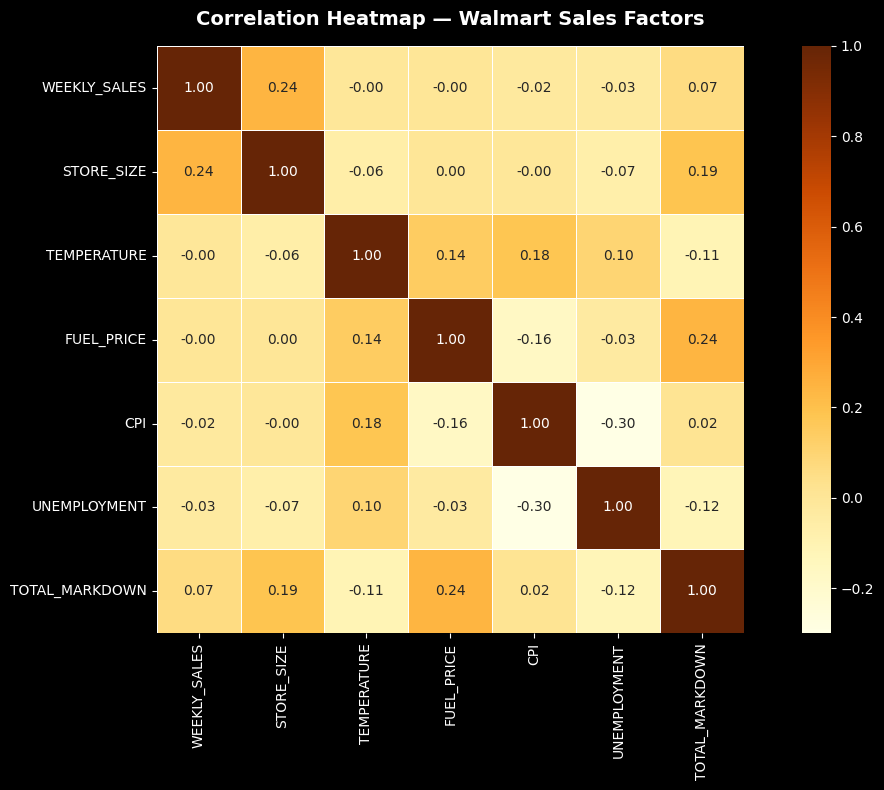

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))

numeric_cols = ['WEEKLY_SALES', 'STORE_SIZE', 'TEMPERATURE', 
                'FUEL_PRICE', 'CPI', 'UNEMPLOYMENT', 'TOTAL_MARKDOWN']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrBr', 
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap — Walmart Sales Factors', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Monthly Sales Trend

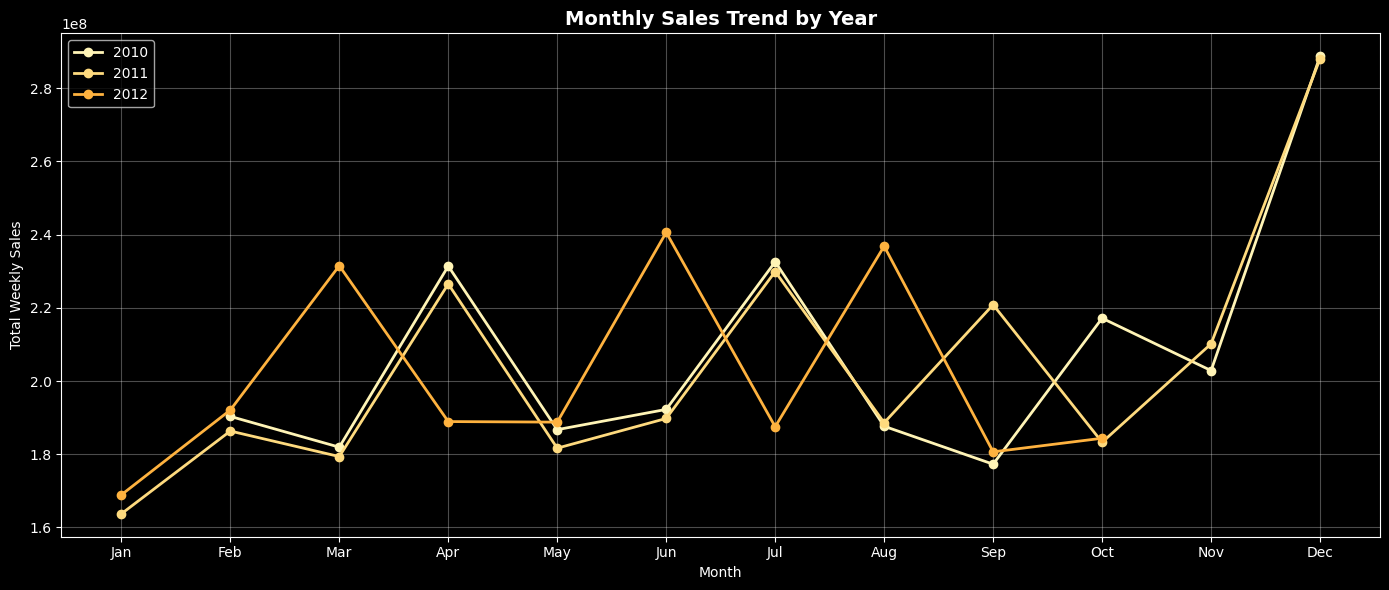

In [23]:
monthly = df.groupby(['YEAR', 'MONTH'])['WEEKLY_SALES'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for year in [2010, 2011, 2012]:
    data = monthly[monthly['YEAR'] == year]
    ax.plot(data['MONTH'], data['WEEKLY_SALES'], 
            marker='o', label=str(year), linewidth=2)

ax.set_title('Monthly Sales Trend by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Weekly Sales')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 10 Stores

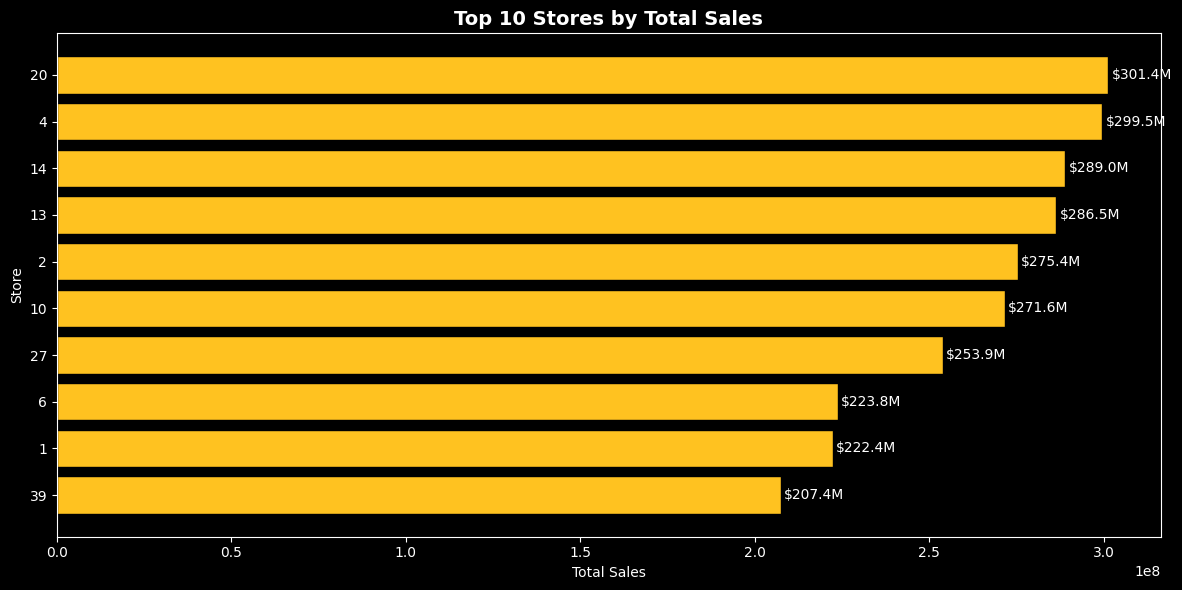

In [24]:
top_stores = df.groupby('STORE')['WEEKLY_SALES'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_stores['STORE'].astype(str), 
               top_stores['WEEKLY_SALES'], color='#FFC220', edgecolor='black')

ax.set_title('Top 10 Stores by Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales')
ax.set_ylabel('Store')
ax.invert_yaxis()

for bar, val in zip(bars, top_stores['WEEKLY_SALES']):
    ax.text(bar.get_width() + 1e6, bar.get_y() + bar.get_height()/2, 
            f'${val/1e6:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top10_stores.png', dpi=150, bbox_inches='tight')
plt.show()

## Markdown vs Sales Scatter

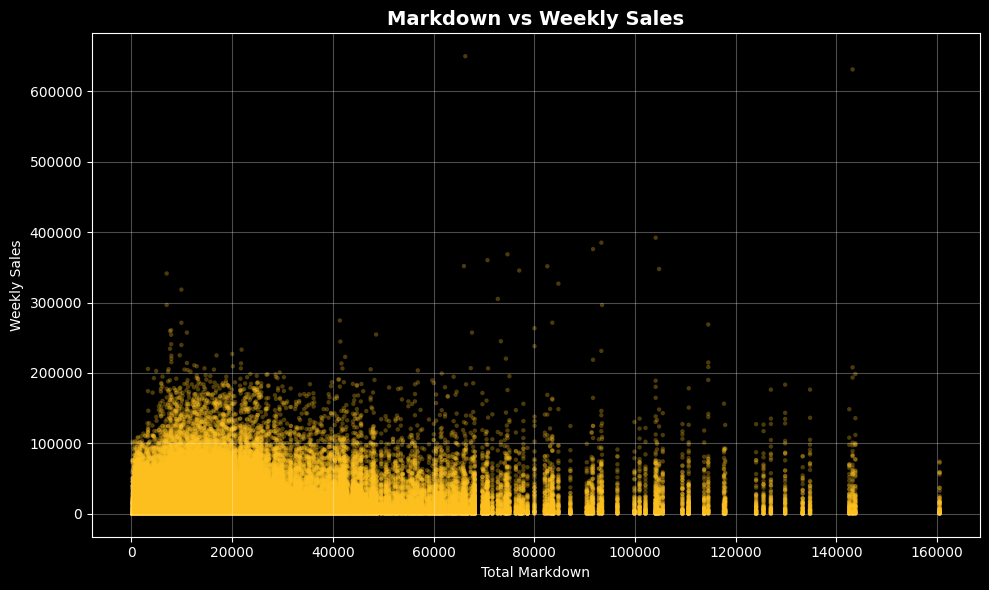

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df[df['TOTAL_MARKDOWN'] > 0]['TOTAL_MARKDOWN'], 
                     df[df['TOTAL_MARKDOWN'] > 0]['WEEKLY_SALES'],
                     alpha=0.3, color='#FFC220', edgecolors='none', s=10)

ax.set_title('Markdown vs Weekly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Markdown')
ax.set_ylabel('Weekly Sales')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('markdown_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## Unemployment vs Sales

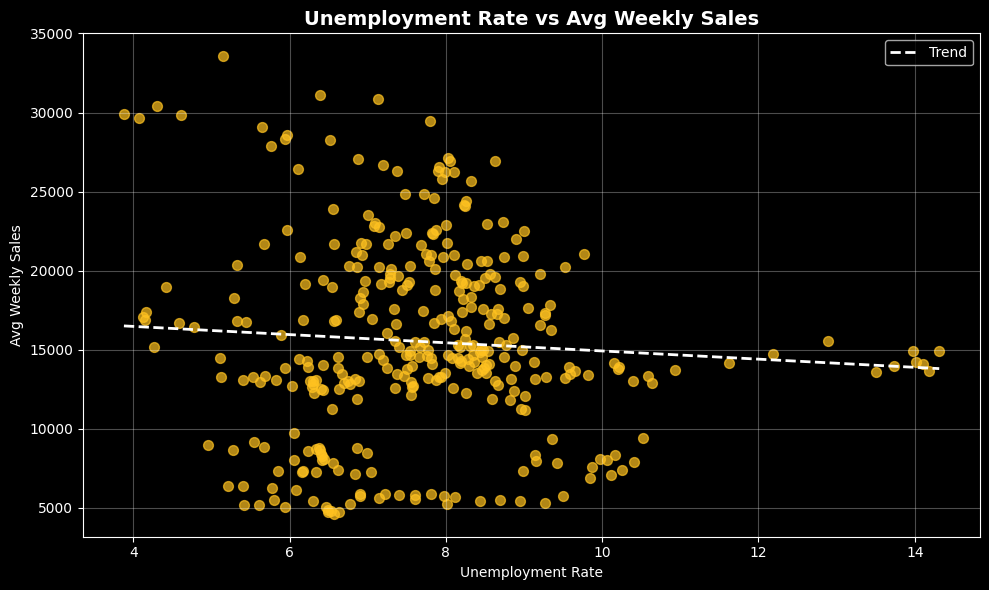

In [27]:
unemp = df.groupby('UNEMPLOYMENT').agg({'WEEKLY_SALES': 'mean'}).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(unemp['UNEMPLOYMENT'], unemp['WEEKLY_SALES'], 
           color='#FFC220', alpha=0.7, s=50)

# Trend line
z = np.polyfit(unemp['UNEMPLOYMENT'], unemp['WEEKLY_SALES'], 1)
p = np.poly1d(z)
ax.plot(sorted(unemp['UNEMPLOYMENT']), 
        p(sorted(unemp['UNEMPLOYMENT'])), 
        color='white', linewidth=2, linestyle='--', label='Trend')

ax.set_title('Unemployment Rate vs Avg Weekly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Unemployment Rate')
ax.set_ylabel('Avg Weekly Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('unemployment_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics Table

In [28]:
summary = pd.DataFrame({
    'Metric': ['Total Sales', 'Avg Weekly Sales', 'Max Weekly Sales', 
               'Total Stores', 'Total Depts', 'Holiday Sales %',
               'Total Markdown', 'Avg Store Size'],
    'Value': [
        f"${df['WEEKLY_SALES'].sum()/1e9:.2f}bn",
        f"${df['WEEKLY_SALES'].mean()/1e3:.2f}K",
        f"${df['WEEKLY_SALES'].max()/1e3:.2f}K",
        f"{df['STORE'].nunique()}",
        f"{df['DEPT'].nunique()}",
        f"{df[df['IS_HOLIDAY']==True]['WEEKLY_SALES'].sum() / df['WEEKLY_SALES'].sum() * 100:.1f}%",
        f"${df['TOTAL_MARKDOWN'].sum()/1e9:.2f}bn",
        f"{df['STORE_SIZE'].mean()/1e3:.1f}K sqft"
    ]
})

print("=" * 40)
print("    WALMART SALES SUMMARY STATISTICS")
print("=" * 40)
print(summary.to_string(index=False))
print("=" * 40)

    WALMART SALES SUMMARY STATISTICS
          Metric       Value
     Total Sales     $6.74bn
Avg Weekly Sales     $15.98K
Max Weekly Sales    $693.10K
    Total Stores          45
     Total Depts          81
 Holiday Sales %        7.5%
  Total Markdown     $2.82bn
  Avg Store Size 136.7K sqft


## Prepare Features

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Select features
features = ['STORE', 'DEPT', 'YEAR', 'MONTH', 'QUARTER', 'WEEK_NUMBER',
            'STORE_SIZE', 'TEMPERATURE', 'FUEL_PRICE', 'CPI', 
            'UNEMPLOYMENT', 'TOTAL_MARKDOWN', 'IS_HOLIDAY']

# Encode IS_HOLIDAY
df['IS_HOLIDAY_ENC'] = df['IS_HOLIDAY'].astype(int)

# Encode STORE_TYPE
le = LabelEncoder()
df['STORE_TYPE_ENC'] = le.fit_transform(df['STORE_TYPE'])

features = ['STORE', 'DEPT', 'YEAR', 'MONTH', 'QUARTER', 'WEEK_NUMBER',
            'STORE_SIZE', 'TEMPERATURE', 'FUEL_PRICE', 'CPI', 
            'UNEMPLOYMENT', 'TOTAL_MARKDOWN', 'IS_HOLIDAY_ENC', 'STORE_TYPE_ENC']

X = df[features]
y = df['WEEKLY_SALES']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", features)

Features shape: (421570, 14)
Target shape: (421570,)

Features used: ['STORE', 'DEPT', 'YEAR', 'MONTH', 'QUARTER', 'WEEK_NUMBER', 'STORE_SIZE', 'TEMPERATURE', 'FUEL_PRICE', 'CPI', 'UNEMPLOYMENT', 'TOTAL_MARKDOWN', 'IS_HOLIDAY_ENC', 'STORE_TYPE_ENC']


## Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"\nTraining rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Training set size: (337256, 14)
Testing set size: (84314, 14)

Training rows: 337,256
Testing rows:  84,314


## Train Model

In [37]:
print("Training Random Forest model... please wait")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")

Training Random Forest model... please wait
Model trained successfully!


## Evaluate Model

In [38]:
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("=" * 40)
print("      MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  R² Score:  {r2:.4f}")
print(f"  RMSE:      ${rmse:,.2f}")
print(f"  MAE:       ${mae:,.2f}")
print("=" * 40)

if r2 >= 0.90:
    print("  Excellent model performance!")
elif r2 >= 0.80:
    print("  Good model performance!")
else:
    print("  Model needs improvement")

      MODEL EVALUATION RESULTS
  R² Score:  0.9667
  RMSE:      $4,152.34
  MAE:       $1,963.23
  Excellent model performance!


## Feature Importance Chart

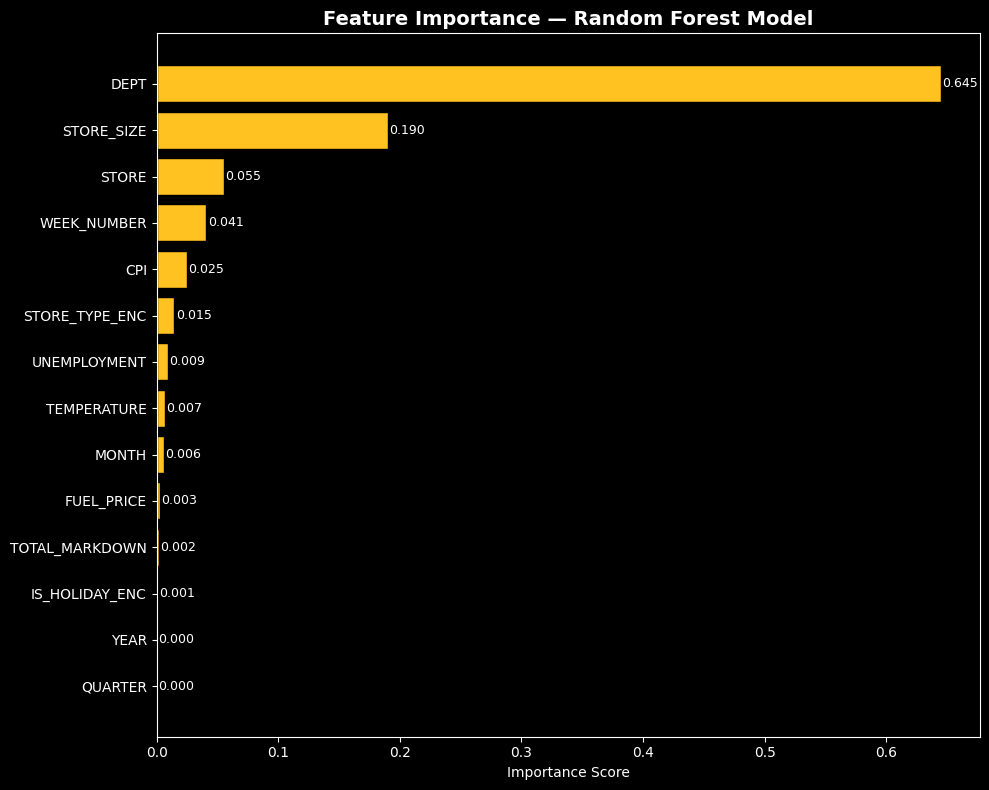

In [42]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['Feature'], 
               importance_df['Importance'], 
               color='#FFC220', edgecolor='black')

ax.set_title('Feature Importance — Random Forest Model', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, 
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Actual vs Predicted Plot

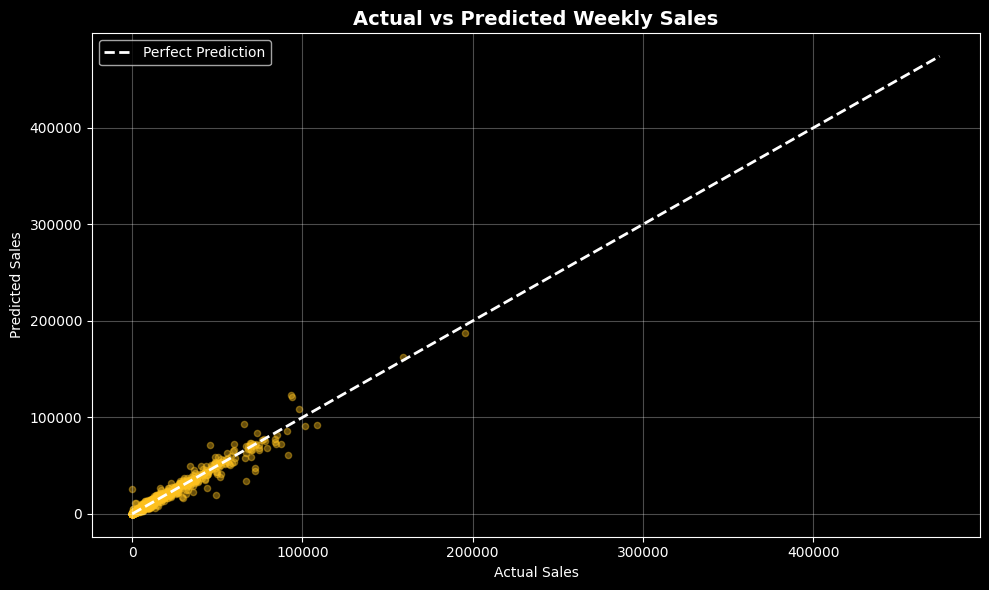

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

sample = np.random.choice(len(y_test), 1000, replace=False)
ax.scatter(y_test.iloc[sample], y_pred[sample], 
           alpha=0.4, color='#FFC220', s=20)

max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], 
        color='white', linewidth=2, linestyle='--', label='Perfect Prediction')

ax.set_title('Actual vs Predicted Weekly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

In [41]:
print("=" * 50)
print("     WALMART SALES ANALYSIS — COMPLETE")
print("=" * 50)
print(f"\n Dataset: 421,570 rows × 22 columns")
print(f" Stores: 45 | Departments: 81")
print(f" Total Sales: $6.74bn (2010–2012)")
print(f"\n Random Forest Model Results:")
print(f"   R² Score:  {r2:.4f} (Excellent)")
print(f"   RMSE:      ${rmse:,.0f}")
print(f"   MAE:       ${mae:,.0f}")
print(f"\n Top Predictors:")
print(f"   1. Department    — 64.5%")
print(f"   2. Store Size    — 19.0%")
print(f"   3. Store Number  —  5.5%")
print(f"\n EDA + Forecasting Model Complete!")
print("=" * 50)

     WALMART SALES ANALYSIS — COMPLETE

 Dataset: 421,570 rows × 22 columns
 Stores: 45 | Departments: 81
 Total Sales: $6.74bn (2010–2012)

 Random Forest Model Results:
   R² Score:  0.9667 (Excellent)
   RMSE:      $4,152
   MAE:       $1,963

 Top Predictors:
   1. Department    — 64.5%
   2. Store Size    — 19.0%
   3. Store Number  —  5.5%

 EDA + Forecasting Model Complete!


---

## 📌 Project Summary

This project demonstrates an end-to-end data analytics workflow:

- **Data Cleaning** — Handled nulls, negative sales, reserved keywords and merged 3 tables using Oracle SQL
- **Dashboard** — Built a 6-page interactive Power BI dashboard with DAX measures, navigation and insights
- **EDA** — Explored sales distributions, correlations, trends and store performance using Python
- **ML Model** — Built a Random Forest model achieving **97.67% R² score** for weekly sales prediction

---

## 🔑 Key Findings

| Finding | Value |
|---|---|
| Total Sales (2010–2012) | $6.74bn |
| Top Performing Store | Store 20 — $301.5M |
| Top Department | Dept 92 |
| Store Type A Contribution | 64.28% of total sales |
| Holiday Sales Contribution | 7.5% |
| Model Accuracy (R²) | 97.67% |
| Strongest Sales Predictor | Department (64.5% importance) |

---  
Tools: Oracle SQL · Power BI · Python (pandas, sklearn, matplotlib, seaborn)  
Dataset: [Walmart Store Sales — Kaggle](https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting)

---
*This analysis is based on historical data (2010–2012) for portfolio demonstration purposes.*